# Dense Models for Tabular Prediction and California Housing Regression

This notebook applies TensorFlow dense models to tabular prediction. It begins with grade-based linear regression, binary classification, multiclass classification, and hidden-layer models, then develops a larger California Housing regression study covering scaling, linear depth, nonlinear hidden layers, width, and depth.

All distinct model variants and recorded results from the supplied tabular-network work are retained.

## Grade Prediction and Classification with TensorFlow

A small tabular grade dataset is used to progress from linear regression to logistic classification and hidden-layer networks.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from google.colab import files
import tensorflow as tf
from keras.utils import plot_model
import time
from keras import activations
from keras.layers import *
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix

In [ ]:
from pathlib import Path

data_candidates = [
    Path("data/grades.xlsx"),
    Path("../data/grades.xlsx"),
    Path("grades.xlsx"),
]
data_path = next((p for p in data_candidates if p.exists()), None)

if data_path is None:
    files.upload()
    data_path = Path("grades.xlsx")

df = pd.read_excel(data_path)
df
X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df.loc[:,'Final Grade'].to_numpy()


# Linear Regression

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

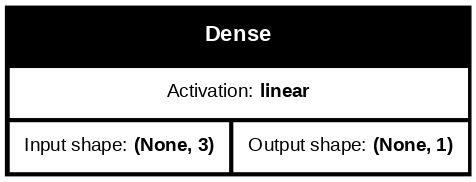

In [ ]:
def linear_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs))
  return model

model = linear_regression(X.shape[1], 1)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

In [ ]:
model.fit(X, y, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X)
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))

Epoch 1/40
5/5 - 1s - 136ms/step - loss: 706.6569
Epoch 2/40
5/5 - 0s - 14ms/step - loss: 310.6822
Epoch 3/40
5/5 - 0s - 28ms/step - loss: 225.9091
Epoch 4/40
5/5 - 0s - 28ms/step - loss: 69.3575
Epoch 5/40
5/5 - 0s - 28ms/step - loss: 83.6389
Epoch 6/40
5/5 - 0s - 26ms/step - loss: 50.8671
Epoch 7/40
5/5 - 0s - 10ms/step - loss: 23.4974
Epoch 8/40
5/5 - 0s - 9ms/step - loss: 27.5487
Epoch 9/40
5/5 - 0s - 8ms/step - loss: 19.5631
Epoch 10/40
5/5 - 0s - 8ms/step - loss: 13.8327
Epoch 11/40
5/5 - 0s - 12ms/step - loss: 11.5841
Epoch 12/40
5/5 - 0s - 9ms/step - loss: 9.8440
Epoch 13/40
5/5 - 0s - 8ms/step - loss: 7.9596
Epoch 14/40
5/5 - 0s - 12ms/step - loss: 7.6112
Epoch 15/40
5/5 - 0s - 12ms/step - loss: 6.7918
Epoch 16/40
5/5 - 0s - 8ms/step - loss: 6.1108
Epoch 17/40
5/5 - 0s - 9ms/step - loss: 6.1273
Epoch 18/40
5/5 - 0s - 12ms/step - loss: 6.1464
Epoch 19/40
5/5 - 0s - 8ms/step - loss: 5.9387
Epoch 20/40
5/5 - 0s - 8ms/step - loss: 5.6240
Epoch 21/40
5/5 - 0s - 8ms/step - loss: 5.7

Epoch 1/40
5/5 - 0s - 87ms/step - loss: 566.8498
Epoch 2/40
5/5 - 0s - 12ms/step - loss: 223.7638
Epoch 3/40
5/5 - 0s - 12ms/step - loss: 205.1441
Epoch 4/40
5/5 - 0s - 12ms/step - loss: 129.9194
Epoch 5/40
5/5 - 0s - 12ms/step - loss: 70.1921
Epoch 6/40
5/5 - 0s - 9ms/step - loss: 37.8926
Epoch 7/40
5/5 - 0s - 12ms/step - loss: 29.2152
Epoch 8/40
5/5 - 0s - 12ms/step - loss: 16.5095
Epoch 9/40
5/5 - 0s - 12ms/step - loss: 10.3888
Epoch 10/40
5/5 - 0s - 12ms/step - loss: 9.0211
Epoch 11/40
5/5 - 0s - 9ms/step - loss: 7.0640
Epoch 12/40
5/5 - 0s - 8ms/step - loss: 7.6718
Epoch 13/40
5/5 - 0s - 8ms/step - loss: 6.9132
Epoch 14/40
5/5 - 0s - 8ms/step - loss: 6.5660
Epoch 15/40
5/5 - 0s - 12ms/step - loss: 5.9124
Epoch 16/40
5/5 - 0s - 12ms/step - loss: 5.6282
Epoch 17/40
5/5 - 0s - 9ms/step - loss: 5.6994
Epoch 18/40
5/5 - 0s - 15ms/step - loss: 5.6162
Epoch 19/40
5/5 - 0s - 9ms/step - loss: 5.5335
Epoch 20/40
5/5 - 0s - 8ms/step - loss: 5.6480
Epoch 21/40
5/5 - 0s - 12ms/step - loss: 5.7

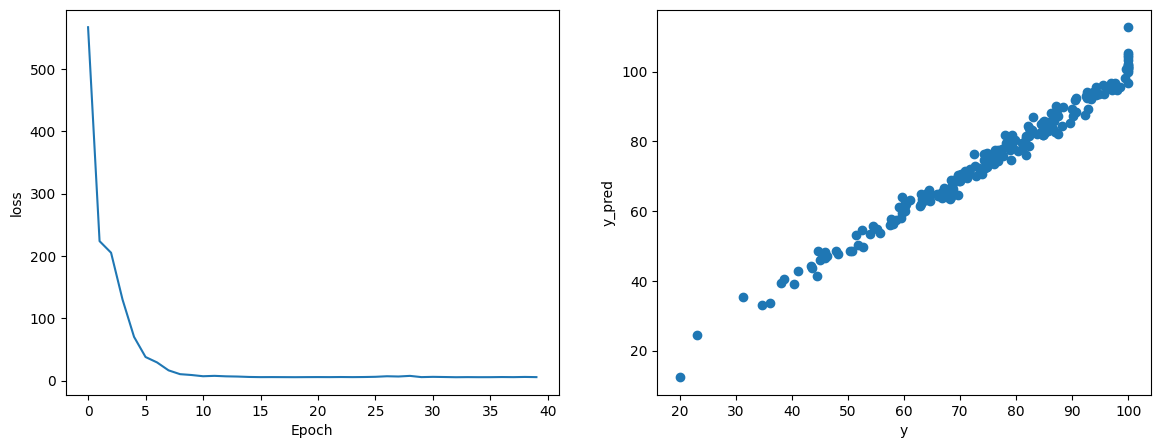

In [ ]:
model = linear_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
history = model.fit(X, y, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X)
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

Usually, performance can be improved if we scale the input and output data to the 0 to 1 range, and the re-scale, if necessary.

Epoch 1/40
5/5 - 1s - 236ms/step - loss: 2.6618
Epoch 2/40
5/5 - 0s - 40ms/step - loss: 0.1693
Epoch 3/40
5/5 - 0s - 40ms/step - loss: 0.5016
Epoch 4/40
5/5 - 0s - 18ms/step - loss: 0.4335
Epoch 5/40
5/5 - 0s - 18ms/step - loss: 0.0737
Epoch 6/40
5/5 - 0s - 37ms/step - loss: 0.1016
Epoch 7/40
5/5 - 0s - 62ms/step - loss: 0.1232
Epoch 8/40
5/5 - 0s - 15ms/step - loss: 0.0402
Epoch 9/40
5/5 - 0s - 14ms/step - loss: 0.0460
Epoch 10/40
5/5 - 0s - 12ms/step - loss: 0.0466
Epoch 11/40
5/5 - 0s - 13ms/step - loss: 0.0273
Epoch 12/40
5/5 - 0s - 13ms/step - loss: 0.0309
Epoch 13/40
5/5 - 0s - 17ms/step - loss: 0.0262
Epoch 14/40
5/5 - 0s - 13ms/step - loss: 0.0219
Epoch 15/40
5/5 - 0s - 8ms/step - loss: 0.0215
Epoch 16/40
5/5 - 0s - 8ms/step - loss: 0.0189
Epoch 17/40
5/5 - 0s - 8ms/step - loss: 0.0176
Epoch 18/40
5/5 - 0s - 8ms/step - loss: 0.0164
Epoch 19/40
5/5 - 0s - 8ms/step - loss: 0.0151
Epoch 20/40
5/5 - 0s - 12ms/step - loss: 0.0140
Epoch 21/40
5/5 - 0s - 12ms/step - loss: 0.0131
Epoch

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Mean squared error = 29.613


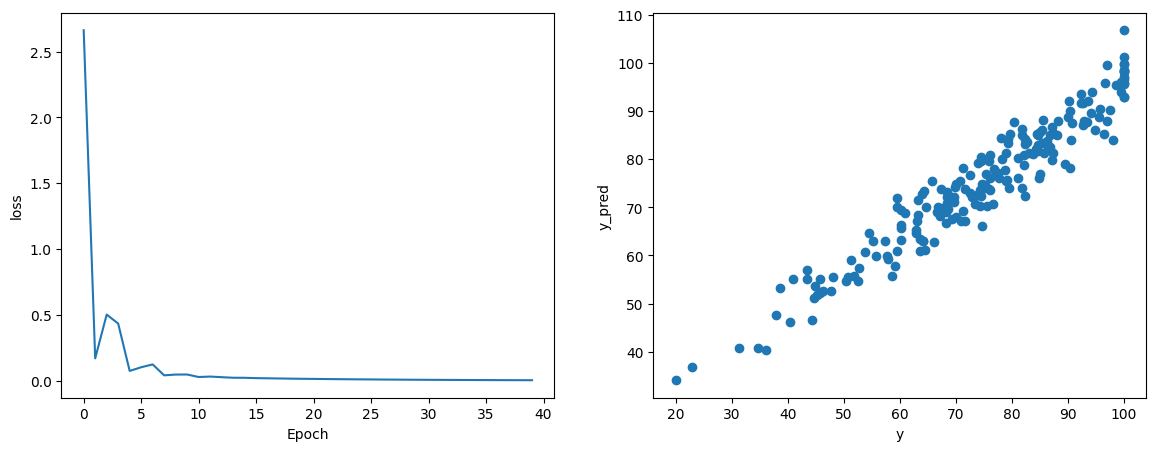

In [ ]:
model = linear_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse")
history = model.fit(X/100, y/100, epochs = 40, batch_size = 40, verbose = 2)
y_pred = model.predict(X/100)*100
print('Mean squared error = {:5.3f}'.format(mean_squared_error(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].scatter(y,y_pred)
ax[1].set_xlabel('y')
ax[1].set_ylabel('y_pred')
plt.show()

# Logistic Regression

## Binary classification

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4 (16.00 B)

 Trainable params: 4 (16.00 B)

 Non-trainable params: 0 (0.00 B)

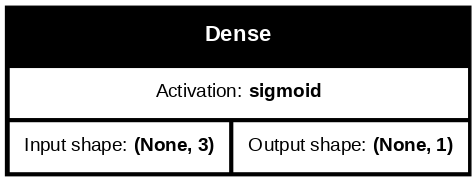

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='sigmoid'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = df.loc[:,'Final Grade'].to_numpy()
y = np.int16(y>=70)

model = logistic_regression(X.shape[1], 1)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/100
10/10 - 1s - 121ms/step - accuracy: 0.6450 - loss: 0.5963
Epoch 2/100
10/10 - 0s - 5ms/step - accuracy: 0.6650 - loss: 0.5470
Epoch 3/100
10/10 - 0s - 5ms/step - accuracy: 0.7600 - loss: 0.5231
Epoch 4/100
10/10 - 0s - 5ms/step - accuracy: 0.7400 - loss: 0.4898
Epoch 5/100
10/10 - 0s - 5ms/step - accuracy: 0.7900 - loss: 0.4629
Epoch 6/100
10/10 - 0s - 6ms/step - accuracy: 0.8400 - loss: 0.4444
Epoch 7/100
10/10 - 0s - 5ms/step - accuracy: 0.7950 - loss: 0.4268
Epoch 8/100
10/10 - 0s - 6ms/step - accuracy: 0.8400 - loss: 0.4071
Epoch 9/100
10/10 - 0s - 5ms/step - accuracy: 0.8600 - loss: 0.3935
Epoch 10/100
10/10 - 0s - 5ms/step - accuracy: 0.8350 - loss: 0.3810
Epoch 11/100
10/10 - 0s - 5ms/step - accuracy: 0.8550 - loss: 0.3691
Epoch 12/100
10/10 - 0s - 5ms/step - accuracy: 0.8500 - loss: 0.3635
Epoch 13/100
10/10 - 0s - 5ms/step - accuracy: 0.9000 - loss: 0.3517
Epoch 14/100
10/10 - 0s - 6ms/step - accuracy: 0.8700 - loss: 0.3432
Epoch 15/100
10/10 - 0s - 5ms/step - accu

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Accuracy = 0.960


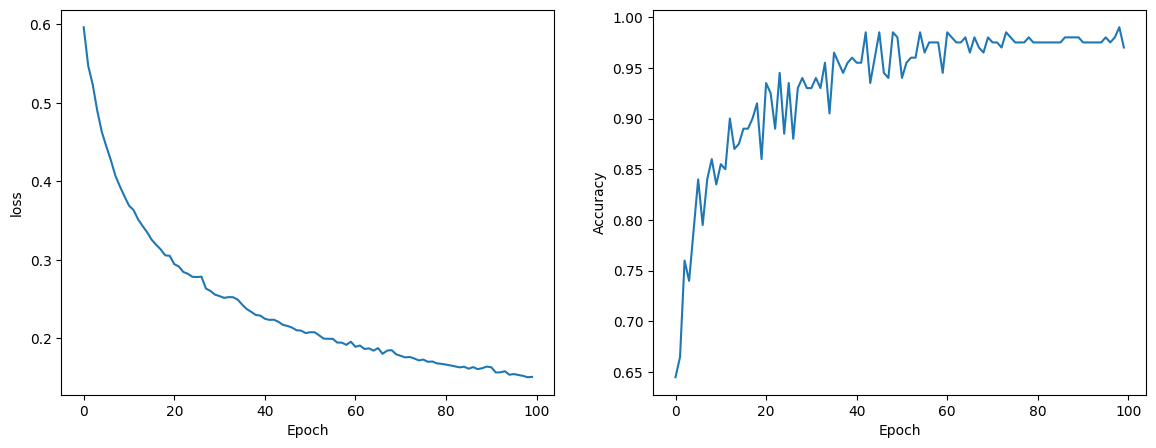

In [ ]:
model = logistic_regression(X.shape[1], 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="binary_crossentropy", metrics=["accuracy"])
history = model.fit(X/100, y, epochs = 100, batch_size = 20, verbose = 2)
y_pred = np.int16(model.predict(X/100)>0.7)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## Multi-class classification

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 5)              │            20 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20 (80.00 B)

 Trainable params: 20 (80.00 B)

 Non-trainable params: 0 (0.00 B)

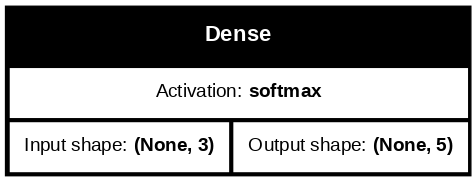

In [ ]:
def logistic_regression(n_inputs, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = np.array(['FDCBA'.index(s) for s in df["Letter"]])
y_oh = tf.keras.utils.to_categorical(y,5)

model = logistic_regression(X.shape[1], 5)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_names=False, show_layer_activations=True,rankdir='LR',dpi=100)

Epoch 1/200
1/1 - 1s - 630ms/step - accuracy: 0.1250 - loss: 1.7413
Epoch 2/200
1/1 - 0s - 67ms/step - accuracy: 0.2100 - loss: 1.6598
Epoch 3/200
1/1 - 0s - 48ms/step - accuracy: 0.1900 - loss: 1.6694
Epoch 4/200
1/1 - 0s - 36ms/step - accuracy: 0.1800 - loss: 1.6266
Epoch 5/200
1/1 - 0s - 36ms/step - accuracy: 0.1900 - loss: 1.5954
Epoch 6/200
1/1 - 0s - 59ms/step - accuracy: 0.2150 - loss: 1.5745
Epoch 7/200
1/1 - 0s - 39ms/step - accuracy: 0.2450 - loss: 1.5467
Epoch 8/200
1/1 - 0s - 58ms/step - accuracy: 0.3100 - loss: 1.5212
Epoch 9/200
1/1 - 0s - 36ms/step - accuracy: 0.5050 - loss: 1.5036
Epoch 10/200
1/1 - 0s - 61ms/step - accuracy: 0.4850 - loss: 1.4856
Epoch 11/200
1/1 - 0s - 56ms/step - accuracy: 0.4550 - loss: 1.4617
Epoch 12/200
1/1 - 0s - 58ms/step - accuracy: 0.4500 - loss: 1.4366
Epoch 13/200
1/1 - 0s - 36ms/step - accuracy: 0.4350 - loss: 1.4165
Epoch 14/200
1/1 - 0s - 36ms/step - accuracy: 0.4350 - loss: 1.4008
Epoch 15/200
1/1 - 0s - 37ms/step - accuracy: 0.4250 - l

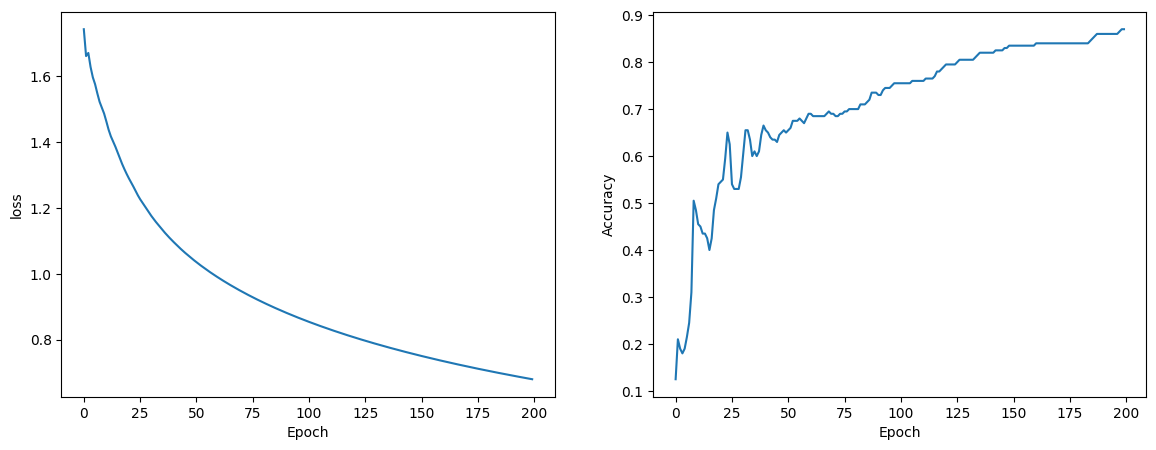

In [ ]:
model = logistic_regression(X.shape[1], 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.2), loss="categorical_crossentropy", metrics=["accuracy"])
#model.compile(loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(X/100, y_oh, epochs = 200, batch_size = 200, verbose = 2)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## Adding a hidden layer

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 10)             │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 5)              │            55 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (380.00 B)

 Trainable params: 95 (380.00 B)

 Non-trainable params: 0 (0.00 B)

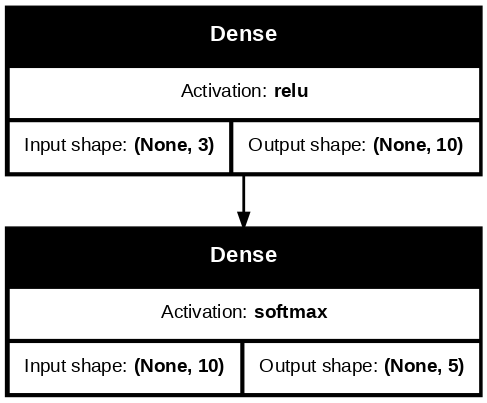

In [ ]:
def three_layer_network(n_inputs, n_hidden, n_outputs):
  model = tf.keras.models.Sequential()
  model.add(Input((n_inputs,)))
  model.add(Dense(n_hidden,activation='relu'))
  model.add(Dense(n_outputs,activation='softmax'))
  return model

X = df.loc[:,['Exam 1', 'Quiz 1', 'Lab 1']].to_numpy()
y = np.array(['FDCBA'.index(s) for s in df["Letter"]])
y_oh = tf.keras.utils.to_categorical(y,5)

model = three_layer_network(X.shape[1], 10, 5)
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.1), loss="mse", metrics=["accuracy"])
plot_model(model, show_shapes=True, show_layer_activations=True,dpi=100)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Accuracy = 0.905


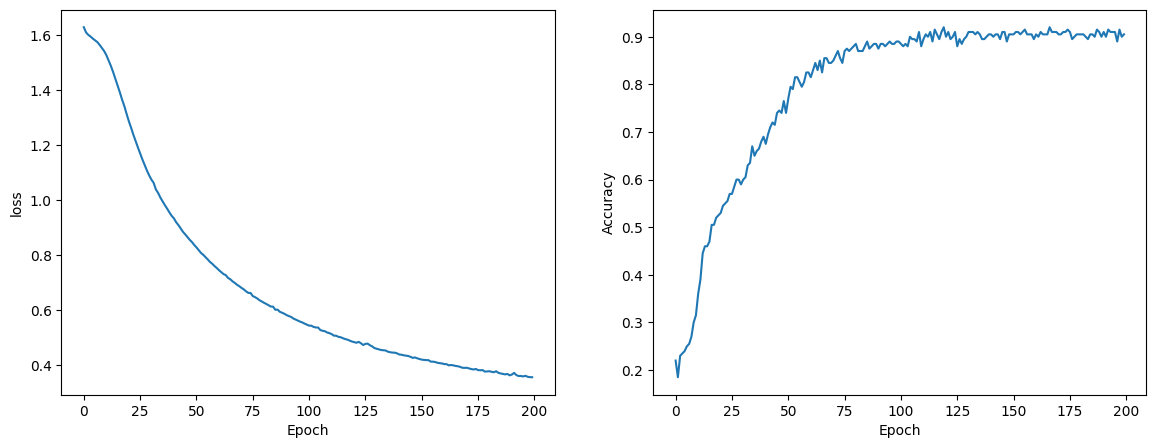

In [ ]:
model = three_layer_network(X.shape[1],10, 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X/100, y_oh, epochs = 200, batch_size = 40, verbose = 0)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
Accuracy = 0.905


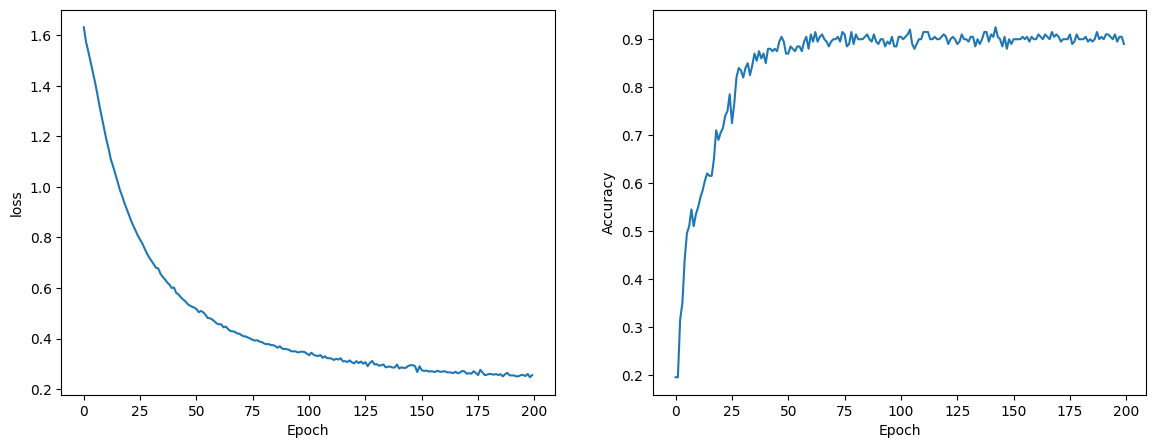

In [ ]:
model = three_layer_network(X.shape[1],50, 5)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), loss="categorical_crossentropy", metrics=["accuracy"])

history = model.fit(X/100, y_oh, epochs = 200, batch_size = 40, verbose = 0)
y_pred = np.argmax(model.predict(X/100),axis=1)

print('Accuracy = {:5.3f}'.format(accuracy_score(y_pred,y)))
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].plot(history.history['loss'])
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('loss')
ax[1].plot(history.history["accuracy"])
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
plt.show()

## California Housing Dense Regression

California Housing is used to study preprocessing and architectural changes in dense regression models.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import tensorflow as tf
from keras.models import Model
from tensorflow.keras.layers import *
from tensorflow.keras.activations import *
from keras.utils import plot_model

In [ ]:
from sklearn.datasets import fetch_california_housing
dataset = fetch_california_housing()
x = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=5361)
print(X_train.shape)
model = LinearRegression()
model.fit(X_train,y_train)
pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))

(16512, 8)
Mean squared error = 0.54565
Mean absolute error =  0.54147


In [ ]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=1)
  ax.plot(history.history['loss'],label = 'train')
  ax.plot(history.history['val_loss'],label = 'test')
  ax.set_title('Loss')
  ax.legend(loc='upper right')

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 1s - 6ms/step - loss: 267982.9688 - val_loss: 1102.0944
Epoch 2/30
166/166 - 0s - 3ms/step - loss: 759.5554 - val_loss: 511.8469
Epoch 3/30
166/166 - 1s - 4ms/step - loss: 322.1906 - val_loss: 189.8600
Epoch 4/30
166/166 - 0s - 3ms/step - loss: 117.8984 - val_loss: 66.1254
Epoch 5/30
166/166 - 1s - 3ms/step - loss: 46.5160 - val_loss: 29.0630
Epoch 6/30
166/166 - 0s - 2ms/step - loss: 25.4669 - val_loss: 18.9563
Epoch 7/30
166/166 - 1s - 4ms/step - loss: 18.5635 - val_loss: 15.2273
Epoch 8/30
166/166 - 1s - 3ms/step - loss: 14.8790 - val_loss: 12.6041
Epoch 9/30
166/166 - 1s - 4ms/step - loss: 12.1216 - val_loss: 11.1524
Epoch 10/30
166/166 - 1s - 3ms/step - loss: 9.9795 - val_loss: 8.9367
Epoch 11/30
166/166 - 1s - 4ms/step - loss: 8.1750 - val_loss: 7.7348
Epoch 12/30
166/166 - 1s - 4ms/step - loss: 6.7735 - val_loss: 6.5917
Epoch 13/30
166/166 - 1s - 4ms/step - loss: 5.6447 - val_loss: 5.5440
Epoch 14/30
166/166 - 1s - 5ms/step - loss: 4.7120 - val_loss: 4.7311


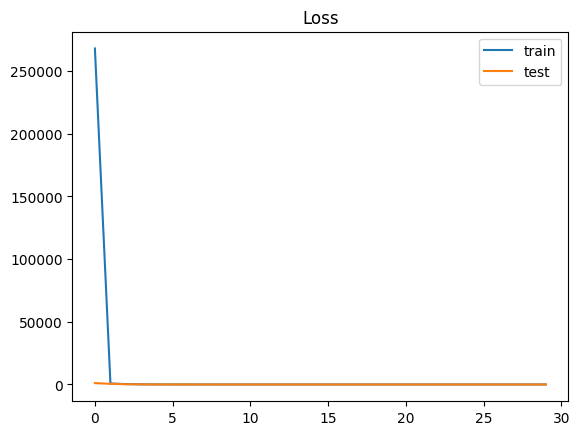

In [ ]:
history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Scaling the data**

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
dataset = fetch_california_housing()
X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=0.20, random_state=5361)
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 1s - 6ms/step - loss: 2.4829 - val_loss: 1.1960
Epoch 2/30
166/166 - 0s - 3ms/step - loss: 1.1342 - val_loss: 1.0797
Epoch 3/30
166/166 - 1s - 4ms/step - loss: 1.0259 - val_loss: 0.9715
Epoch 4/30
166/166 - 1s - 3ms/step - loss: 0.9258 - val_loss: 0.8769
Epoch 5/30
166/166 - 0s - 3ms/step - loss: 0.8402 - val_loss: 0.7997
Epoch 6/30
166/166 - 1s - 3ms/step - loss: 0.7705 - val_loss: 0.7390
Epoch 7/30
166/166 - 0s - 3ms/step - loss: 0.7170 - val_loss: 0.6944
Epoch 8/30
166/166 - 1s - 4ms/step - loss: 0.6772 - val_loss: 0.6625
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.6491 - val_loss: 0.6409
Epoch 10/30
166/166 - 1s - 4ms/step - loss: 0.6296 - val_loss: 0.6266
Epoch 11/30
166/166 - 1s - 4ms/step - loss: 0.6160 - val_loss: 0.6170
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.6067 - val_loss: 0.6106
Epoch 13/30
166/166 - 0s - 2ms/step - loss: 0.6000 - val_loss: 0.6056
Epoch 14/30
166/166 - 1s - 4ms/step - loss: 0.5944 - val_loss: 0.6063
Epoch 15/30
166/166 - 1s - 4m

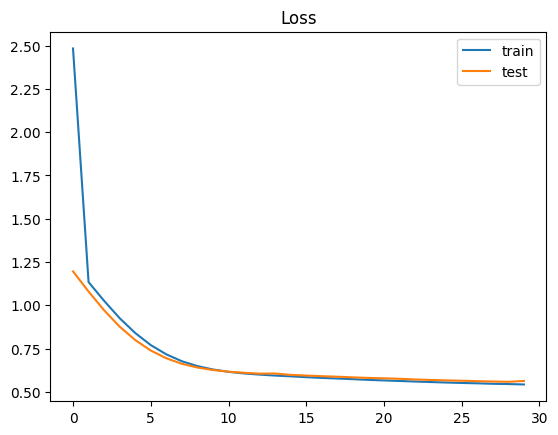

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Adding another linear layer**

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 15ms/step - loss: 1.1959 - val_loss: 0.6658
Epoch 2/30
166/166 - 2s - 13ms/step - loss: 0.6094 - val_loss: 0.5976
Epoch 3/30
166/166 - 1s - 5ms/step - loss: 0.5750 - val_loss: 0.5889
Epoch 4/30
166/166 - 1s - 8ms/step - loss: 0.5597 - val_loss: 0.5691
Epoch 5/30
166/166 - 0s - 2ms/step - loss: 0.5432 - val_loss: 0.5517
Epoch 6/30
166/166 - 0s - 2ms/step - loss: 0.5409 - val_loss: 0.5638
Epoch 7/30
166/166 - 0s - 2ms/step - loss: 0.5350 - val_loss: 0.5512
Epoch 8/30
166/166 - 1s - 4ms/step - loss: 0.5330 - val_loss: 0.5522
Epoch 9/30
166/166 - 0s - 2ms/step - loss: 0.5307 - val_loss: 0.5434
Epoch 10/30
166/166 - 1s - 4ms/step - loss: 0.5305 - val_loss: 0.5473
Epoch 11/30
166/166 - 1s - 4ms/step - loss: 0.5326 - val_loss: 0.5468
Epoch 12/30
166/166 - 1s - 4ms/step - loss: 0.5283 - val_loss: 0.5482
Epoch 13/30
166/166 - 1s - 8ms/step - loss: 0.5322 - val_loss: 0.5426
Epoch 14/30
166/166 - 1s - 3ms/step - loss: 0.5291 - val_loss: 0.5467
Epoch 15/30
166/166 - 0s - 

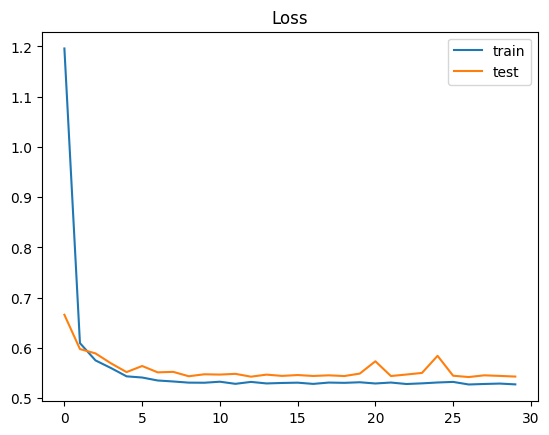

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Adding a non-linear layer**

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 81 (324.00 B)

 Trainable params: 81 (324.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 1s - 8ms/step - loss: 1.8003 - val_loss: 1.1513
Epoch 2/30
166/166 - 1s - 3ms/step - loss: 0.9456 - val_loss: 0.7281
Epoch 3/30
166/166 - 1s - 4ms/step - loss: 0.6418 - val_loss: 0.6116
Epoch 4/30
166/166 - 1s - 4ms/step - loss: 0.5904 - val_loss: 0.5903
Epoch 5/30
166/166 - 1s - 4ms/step - loss: 0.5698 - val_loss: 0.5731
Epoch 6/30
166/166 - 1s - 4ms/step - loss: 0.5492 - val_loss: 0.5658
Epoch 7/30
166/166 - 1s - 4ms/step - loss: 0.5291 - val_loss: 0.5280
Epoch 8/30
166/166 - 0s - 3ms/step - loss: 0.5061 - val_loss: 0.5151
Epoch 9/30
166/166 - 1s - 4ms/step - loss: 0.4948 - val_loss: 0.5075
Epoch 10/30
166/166 - 1s - 4ms/step - loss: 0.4859 - val_loss: 0.5005
Epoch 11/30
166/166 - 1s - 3ms/step - loss: 0.4798 - val_loss: 0.4937
Epoch 12/30
166/166 - 1s - 4ms/step - loss: 0.4753 - val_loss: 0.4901
Epoch 13/30
166/166 - 0s - 2ms/step - loss: 0.4727 - val_loss: 0.4886
Epoch 14/30
166/166 - 1s - 4ms/step - loss: 0.4712 - val_loss: 0.4867
Epoch 15/30
166/166 - 0s - 2m

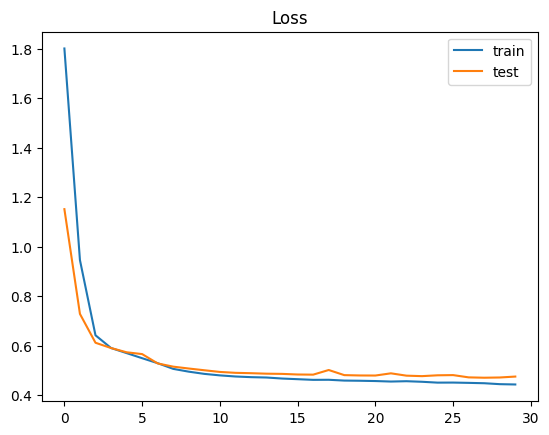

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Increasing the width**

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 16)                  │             144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161 (644.00 B)

 Trainable params: 161 (644.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 1s - 9ms/step - loss: 1.0245 - val_loss: 0.6039
Epoch 2/30
166/166 - 1s - 7ms/step - loss: 0.5754 - val_loss: 0.5880
Epoch 3/30
166/166 - 1s - 4ms/step - loss: 0.5454 - val_loss: 0.5555
Epoch 4/30
166/166 - 1s - 7ms/step - loss: 0.5209 - val_loss: 0.5233
Epoch 5/30
166/166 - 1s - 4ms/step - loss: 0.5029 - val_loss: 0.5204
Epoch 6/30
166/166 - 1s - 4ms/step - loss: 0.4888 - val_loss: 0.5149
Epoch 7/30
166/166 - 0s - 2ms/step - loss: 0.4860 - val_loss: 0.5028
Epoch 8/30
166/166 - 0s - 3ms/step - loss: 0.4791 - val_loss: 0.4930
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4715 - val_loss: 0.5125
Epoch 10/30
166/166 - 1s - 4ms/step - loss: 0.4749 - val_loss: 0.4906
Epoch 11/30
166/166 - 0s - 3ms/step - loss: 0.4664 - val_loss: 0.4871
Epoch 12/30
166/166 - 1s - 3ms/step - loss: 0.4616 - val_loss: 0.4982
Epoch 13/30
166/166 - 1s - 4ms/step - loss: 0.4625 - val_loss: 0.4807
Epoch 14/30
166/166 - 0s - 2ms/step - loss: 0.4550 - val_loss: 0.4757
Epoch 15/30
166/166 - 1s - 4m

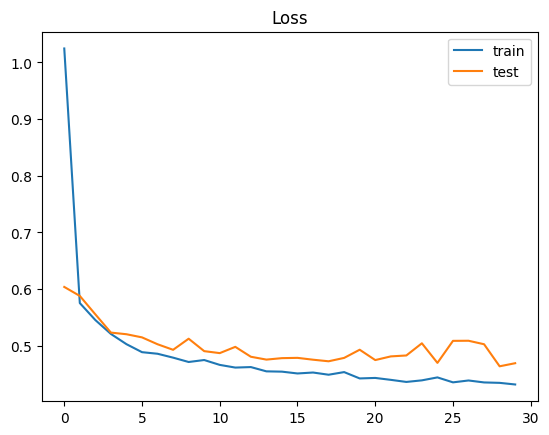

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

**Increasing the depth**

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                     │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 8)                   │              72 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 13ms/step - loss: 1.3528 - val_loss: 0.6248
Epoch 2/30
166/166 - 1s - 5ms/step - loss: 0.5765 - val_loss: 0.5821
Epoch 3/30
166/166 - 0s - 3ms/step - loss: 0.5359 - val_loss: 0.5507
Epoch 4/30
166/166 - 0s - 3ms/step - loss: 0.5086 - val_loss: 0.5206
Epoch 5/30
166/166 - 1s - 4ms/step - loss: 0.4973 - val_loss: 0.5170
Epoch 6/30
166/166 - 1s - 4ms/step - loss: 0.4874 - val_loss: 0.5083
Epoch 7/30
166/166 - 1s - 4ms/step - loss: 0.4855 - val_loss: 0.5004
Epoch 8/30
166/166 - 1s - 4ms/step - loss: 0.4735 - val_loss: 0.4952
Epoch 9/30
166/166 - 1s - 4ms/step - loss: 0.4676 - val_loss: 0.5211
Epoch 10/30
166/166 - 1s - 4ms/step - loss: 0.4695 - val_loss: 0.4886
Epoch 11/30
166/166 - 1s - 4ms/step - loss: 0.4637 - val_loss: 0.4762
Epoch 12/30
166/166 - 1s - 4ms/step - loss: 0.4563 - val_loss: 0.4959
Epoch 13/30
166/166 - 1s - 3ms/step - loss: 0.4567 - val_loss: 0.4736
Epoch 14/30
166/166 - 0s - 3ms/step - loss: 0.4566 - val_loss: 0.5006
Epoch 15/30
166/166 - 1s - 4

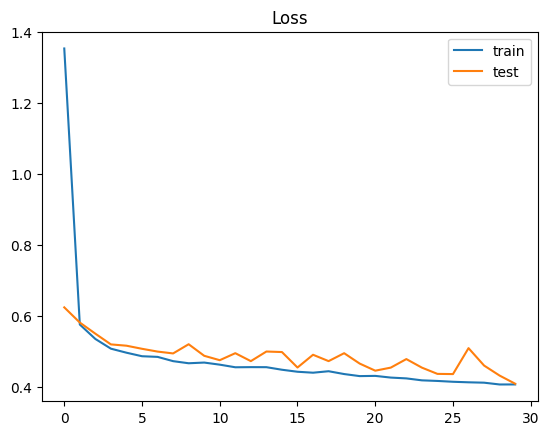

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 64)                  │             576 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
166/166 - 2s - 10ms/step - loss: 0.8337 - val_loss: 0.5825
Epoch 2/30
166/166 - 1s - 7ms/step - loss: 0.5349 - val_loss: 0.5817
Epoch 3/30
166/166 - 1s - 3ms/step - loss: 0.4874 - val_loss: 0.7121
Epoch 4/30
166/166 - 0s - 3ms/step - loss: 0.4839 - val_loss: 0.4769
Epoch 5/30
166/166 - 0s - 3ms/step - loss: 0.4619 - val_loss: 0.4587
Epoch 6/30
166/166 - 1s - 4ms/step - loss: 0.4484 - val_loss: 0.4761
Epoch 7/30
166/166 - 1s - 3ms/step - loss: 0.4458 - val_loss: 0.4656
Epoch 8/30
166/166 - 1s - 4ms/step - loss: 0.4353 - val_loss: 0.4559
Epoch 9/30
166/166 - 1s - 3ms/step - loss: 0.4427 - val_loss: 0.4986
Epoch 10/30
166/166 - 1s - 5ms/step - loss: 0.4412 - val_loss: 0.4382
Epoch 11/30
166/166 - 1s - 8ms/step - loss: 0.4264 - val_loss: 0.4612
Epoch 12/30
166/166 - 1s - 6ms/step - loss: 0.4245 - val_loss: 0.4256
Epoch 13/30
166/166 - 0s - 3ms/step - loss: 0.4158 - val_loss: 0.4386
Epoch 14/30
166/166 - 1s - 4ms/step - loss: 0.4033 - val_loss: 0.4474
Epoch 15/30
166/166 - 1s - 4

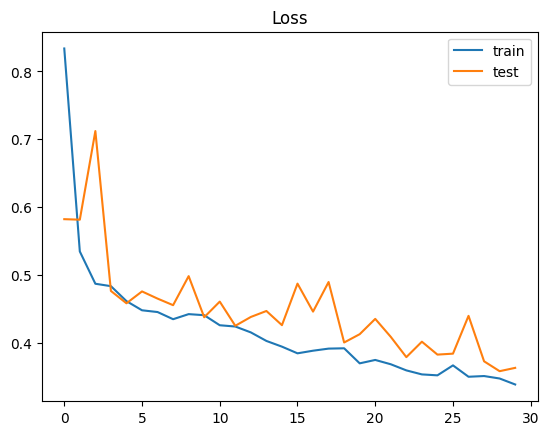

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(64,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 30,
    batch_size = 100,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,353 (267.00 KB)

 Trainable params: 68,353 (267.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
83/83 - 2s - 29ms/step - loss: 0.8059 - val_loss: 0.6326
Epoch 2/60
83/83 - 1s - 13ms/step - loss: 0.5595 - val_loss: 0.5771
Epoch 3/60
83/83 - 1s - 8ms/step - loss: 0.4858 - val_loss: 0.4735
Epoch 4/60
83/83 - 1s - 7ms/step - loss: 0.4621 - val_loss: 0.4819
Epoch 5/60
83/83 - 1s - 6ms/step - loss: 0.4385 - val_loss: 0.4596
Epoch 6/60
83/83 - 1s - 7ms/step - loss: 0.4224 - val_loss: 0.4390
Epoch 7/60
83/83 - 0s - 6ms/step - loss: 0.4601 - val_loss: 0.5750
Epoch 8/60
83/83 - 0s - 6ms/step - loss: 0.4252 - val_loss: 0.4301
Epoch 9/60
83/83 - 1s - 7ms/step - loss: 0.4173 - val_loss: 0.4087
Epoch 10/60
83/83 - 1s - 7ms/step - loss: 0.4028 - val_loss: 0.4544
Epoch 11/60
83/83 - 1s - 7ms/step - loss: 0.3996 - val_loss: 0.3978
Epoch 12/60
83/83 - 0s - 6ms/step - loss: 0.3898 - val_loss: 0.4560
Epoch 13/60
83/83 - 1s - 8ms/step - loss: 0.3844 - val_loss: 0.4712
Epoch 14/60
83/83 - 1s - 6ms/step - loss: 0.3857 - val_loss: 0.4227
Epoch 15/60
83/83 - 1s - 11ms/step - loss: 0.3807 - val

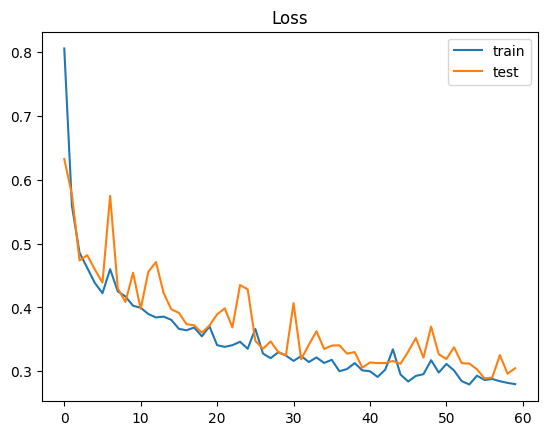

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mse")

history = model.fit(
    X_train, y_train,
    epochs = 60,
    batch_size = 200,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_22 (Dense)                     │ (None, 256)                 │           2,304 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 256)                 │          65,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │             257 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 68,353 (267.00 KB)

 Trainable params: 68,353 (267.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
83/83 - 3s - 35ms/step - loss: 0.6168 - val_loss: 0.5381
Epoch 2/60
83/83 - 1s - 15ms/step - loss: 0.5219 - val_loss: 0.5246
Epoch 3/60
83/83 - 1s - 9ms/step - loss: 0.4953 - val_loss: 0.4884
Epoch 4/60
83/83 - 1s - 9ms/step - loss: 0.4689 - val_loss: 0.4682
Epoch 5/60
83/83 - 1s - 11ms/step - loss: 0.4614 - val_loss: 0.4563
Epoch 6/60
83/83 - 1s - 15ms/step - loss: 0.4572 - val_loss: 0.4775
Epoch 7/60
83/83 - 1s - 12ms/step - loss: 0.4470 - val_loss: 0.4389
Epoch 8/60
83/83 - 1s - 7ms/step - loss: 0.4509 - val_loss: 0.4442
Epoch 9/60
83/83 - 1s - 6ms/step - loss: 0.4334 - val_loss: 0.4559
Epoch 10/60
83/83 - 1s - 8ms/step - loss: 0.4510 - val_loss: 0.4379
Epoch 11/60
83/83 - 1s - 7ms/step - loss: 0.4375 - val_loss: 0.4390
Epoch 12/60
83/83 - 1s - 7ms/step - loss: 0.4352 - val_loss: 0.4300
Epoch 13/60
83/83 - 1s - 8ms/step - loss: 0.4294 - val_loss: 0.4510
Epoch 14/60
83/83 - 1s - 6ms/step - loss: 0.4328 - val_loss: 0.4320
Epoch 15/60
83/83 - 1s - 7ms/step - loss: 0.4336 - v

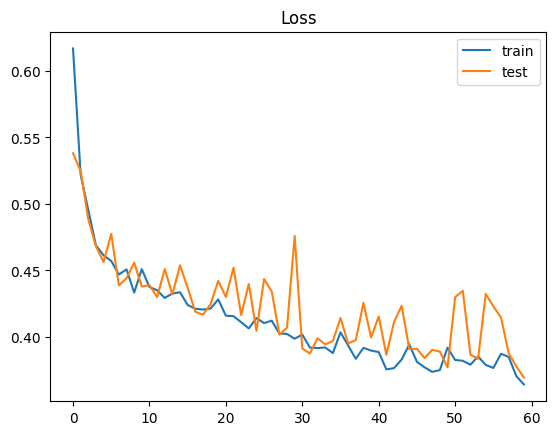

In [ ]:
def ff_model(n_inputs):
  model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(n_inputs,)),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(256,activation='relu'),
    tf.keras.layers.Dense(1)])
  return model

model = ff_model(X_train.shape[1])
model.summary()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate = 0.01),loss="mae")

history = model.fit(
    X_train, y_train,
    epochs = 60,
    batch_size = 200,
    verbose = 2,
    validation_data=(X_test, y_test),
)

pred = model.predict(X_test)
print('Mean squared error = {:.5f}'.format(mean_squared_error(pred,y_test)))
print('Mean absolute error =  {:.5f}'.format(mean_absolute_error(pred,y_test)))
plot_results(history)